In [ ]:
import os, random
from pathlib import Path
import joblib, json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
MIN_OBSERVED_TARGETS = 2
GROUP_COLS = ["Primary Code"]  # grouping variables for joint covariance matrices
LOG_EPS = 1e-6           # small constant: log(y + LOG_EPS)

X_cols = ["Construction period", "Typology", "Primary Code", "Hybrid Structure", "Country"]
y_cols = ["Concrete", "Glass", "Steel", "Wood", "Brick"]


def set_global_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)


set_global_seed(SEED)
print("Imports complete. SEED =", SEED)
print("Joint covariance grouping columns:", GROUP_COLS)

Imports complete. SEED = 42
Joint covariance grouping columns: ['Primary Code']


In [30]:
# ==========================================================
# Data Preparation
# ==========================================================

def build_group_keys(df, group_cols=GROUP_COLS):
    return (
        df.loc[:, group_cols]
        .fillna("Missing")
        .astype(str)
        .agg(" | ".join, axis=1)
        .to_numpy()
    )

def prepare_data(
    file_path="Integrated_MI_database_add_Singapore.xlsx",
    test_size=0.30,
    val_size=0.50,
    clip_upper_quantile=0.99,
    clip_materials=("Steel", "Glass", "Concrete", "Brick", "Wood"),
    min_observed_targets=MIN_OBSERVED_TARGETS,
    random_state=SEED,
):
    # Load, split, and preprocess the MI database.
    # Returns numpy arrays together with raw DataFrames for group-label access.
    file_path = Path(file_path)
    if not file_path.is_absolute():
        file_path = Path.cwd() / file_path

    df = pd.read_excel(file_path)
    df["Construction period"] = pd.to_numeric(df["Construction period"], errors="coerce")
    df = df.dropna(subset=X_cols).reset_index(drop=True)

    target_mask_df = df[y_cols].notna()
    df = df.loc[target_mask_df.sum(axis=1) >= min_observed_targets].reset_index(drop=True)

    X = df[X_cols].copy()
    y_raw_df = df[y_cols].copy()
    y_mask = y_raw_df.notna().to_numpy(dtype=bool)

    X_train, X_temp, y_train_df, y_temp_df, y_train_mask, y_temp_mask = train_test_split(
        X, y_raw_df, y_mask, test_size=test_size, random_state=random_state
    )
    X_val, X_test, y_val_df, y_test_df, y_val_mask, y_test_mask = train_test_split(
        X_temp, y_temp_df, y_temp_mask, test_size=val_size, random_state=random_state
    )

    for df_ in [X_train, X_val, X_test, y_train_df, y_val_df, y_test_df]:
        df_.reset_index(drop=True, inplace=True)

    y_train_raw = y_train_df.to_numpy(dtype=np.float64)
    y_val_raw   = y_val_df.to_numpy(dtype=np.float64)
    y_test_raw  = y_test_df.to_numpy(dtype=np.float64)

    # Upper-quantile clipping on training statistics applied to all splits
    clip_bounds = None
    if clip_upper_quantile is not None:
        mat_to_idx = {m: i for i, m in enumerate(y_cols)}
        upper_bounds = {}
        for mat in clip_materials:
            if mat not in mat_to_idx:
                continue
            idx = mat_to_idx[mat]
            obs = y_train_mask[:, idx]
            if not np.any(obs):
                continue
            ub = np.quantile(y_train_raw[obs, idx], clip_upper_quantile)
            for arr, mask in [(y_train_raw, y_train_mask), (y_val_raw, y_val_mask),
                              (y_test_raw, y_test_mask)]:
                rows = mask[:, idx]
                arr[rows, idx] = np.minimum(arr[rows, idx], ub)
            upper_bounds[mat] = float(ub)
        clip_bounds = {"upper_quantile": clip_upper_quantile, "upper_bounds": upper_bounds}

    preprocessor = ColumnTransformer(transformers=[
        ("num", StandardScaler(), ["Construction period"]),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         ["Typology", "Primary Code", "Hybrid Structure", "Country"]),
    ])
    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc   = preprocessor.transform(X_val)
    X_test_proc  = preprocessor.transform(X_test)

    return dict(
        X_train_proc=X_train_proc, X_val_proc=X_val_proc, X_test_proc=X_test_proc,
        X_train_raw=X_train,       X_val_raw=X_val,        X_test_raw=X_test,
        y_train_raw=y_train_raw,   y_val_raw=y_val_raw,    y_test_raw=y_test_raw,
        y_train_df=y_train_df,     y_val_df=y_val_df,      y_test_df=y_test_df,
        y_train_mask=y_train_mask, y_val_mask=y_val_mask,  y_test_mask=y_test_mask,
        groups_train=build_group_keys(X_train),
        groups_val  =build_group_keys(X_val),
        groups_test =build_group_keys(X_test),
        preprocessor=preprocessor,
        clip_bounds=clip_bounds,
        kept_rows=len(df),
        min_observed_targets=min_observed_targets,
    )


In [31]:
set_global_seed(SEED)
data = prepare_data()

print("Data preparation complete.")
print(f"X_train: {data['X_train_proc'].shape}  y_train: {data['y_train_raw'].shape}")
print(f"X_val:   {data['X_val_proc'].shape}  y_val:   {data['y_val_raw'].shape}")
print(f"X_test:  {data['X_test_proc'].shape}  y_test:  {data['y_test_raw'].shape}")
print(f"Rows kept: {data['kept_rows']}  (min observed targets: {data['min_observed_targets']})")

for split in ["train", "val", "test"]:
    mask = data[f"y_{split}_mask"]
    obs  = mask.sum(axis=1)
    print(f"  {split}: obs/row  min={obs.min()}  mean={obs.mean():.2f}  max={obs.max()}")


Data preparation complete.
X_train: (1799, 47)  y_train: (1799, 5)
X_val:   (385, 47)  y_val:   (385, 5)
X_test:  (386, 47)  y_test:  (386, 5)
Rows kept: 2570  (min observed targets: 2)
  train: obs/row  min=2  mean=3.65  max=5
  val: obs/row  min=2  mean=3.57  max=5
  test: obs/row  min=2  mean=3.69  max=5


In [32]:
# ==========================================================
# Stage 1 — Material Occurrence Model  (binary logistic regression)
#
# Predicts P(a_{i,m} = 1 | x_i) for each material m:
#   logit(p_{i,m}) = alpha_{0,m} + alpha_{1,m}^T x_i
# ==========================================================

class MaterialOccurrenceModel:
    # Per-material binary logistic regression for presence / absence.

    def __init__(self, C=1.0, max_iter=1000, random_state=SEED):
        self.C = C
        self.max_iter = max_iter
        self.random_state = random_state
        self.models_ = {}
        self.trivial_proba_ = {}

    def fit(self, X, y_mask):
        # X      : (N, D) preprocessed feature matrix
        # y_mask : (N, M) bool, True where material is observed
        self.models_ = {}
        self.trivial_proba_ = {}
        for m, material in enumerate(y_cols):
            obs = y_mask[:, m]
            p = float(obs.mean())
            if p == 0.0 or p == 1.0:
                self.trivial_proba_[material] = p
                self.models_[material] = None
                continue
            lr = LogisticRegression(C=self.C, max_iter=self.max_iter,
                                    random_state=self.random_state, solver="lbfgs")
            lr.fit(X, obs.astype(int))
            self.models_[material] = lr
        return self

    def predict_proba(self, X):
        # Returns (N, M) array of material-presence probabilities
        N = X.shape[0]
        proba = np.zeros((N, len(y_cols)), dtype=np.float64)
        for m, material in enumerate(y_cols):
            model = self.models_.get(material)
            if model is None:
                proba[:, m] = self.trivial_proba_.get(material, 1.0)
            else:
                proba[:, m] = model.predict_proba(X)[:, 1]
        return proba


In [33]:
# ==========================================================
# Stage 2 — Conditional Material Intensity Model  (ridge regression)
#
# Conditional on presence, predicts expected log-MI:
#   mu_{i,m} = f_m(x_i)   where f_m is ridge regression on log-targets.
#
# log-transform : y_log = log(y + LOG_EPS)
# inverse       : y_hat = exp(mu) - LOG_EPS  (clipped to >= 0)
# ==========================================================

class MaterialIntensityModel:
    # Per-material ridge regression in log-space for conditional MI estimation.
    # RidgeCV selects regularisation strength via k-fold CV.

    def __init__(self, alphas=(0.01, 0.1, 1.0, 10.0, 100.0, 1000.0)):
        self.alphas = alphas
        self.models_ = {}

    def fit(self, X, y_raw, y_mask):
        # X      : (N, D) preprocessed features
        # y_raw  : (N, M) raw targets (NaN where unobserved)
        # y_mask : (N, M) bool observation mask
        self.models_ = {}
        for m, material in enumerate(y_cols):
            obs = y_mask[:, m]
            if obs.sum() < 2:
                self.models_[material] = None
                continue
            X_obs = X[obs]
            y_log = np.log(y_raw[obs, m] + LOG_EPS)
            # RidgeCV mutates alphas in-place, so pass a fresh mutable list.
            ridge = RidgeCV(alphas=list(self.alphas), cv=5)
            ridge.fit(X_obs, y_log)
            self.models_[material] = ridge
        return self

    def predict_log(self, X):
        # Returns (N, M) predicted log-intensities
        N = X.shape[0]
        mu_log = np.zeros((N, len(y_cols)), dtype=np.float64)
        for m, material in enumerate(y_cols):
            model = self.models_.get(material)
            if model is not None:
                mu_log[:, m] = model.predict(X)
        return mu_log

    def predict(self, X):
        # Returns (N, M) predicted intensities in original (kg/m2) scale
        return np.maximum(np.exp(self.predict_log(X)) - LOG_EPS, 0.0)


In [34]:
# ==========================================================
# Stage 3 - Joint Distribution Layer  (multivariate normal)
#
# Captures inter-material covariance via:
#   z_i | x_i  ~  N_5( mu_i,  Sigma_{g(i)} )
#
# mu_i          : Stage-2 log-predictions
# Sigma_{g(i)}  : empirical covariance of log-space residuals for group g(i)
# Groups defined by Typology
# ==========================================================

DEFAULT_GROUP_COLS = globals().get("GROUP_COLS", ["Primary Code"])

class JointDistributionModel:
    # Group-specific multivariate normal covariance in log-residual space.

    def __init__(self, group_cols=None, min_group_size=20, reg_eps=1e-4, cov_shrink=0.0):
        if group_cols is None:
            group_cols = DEFAULT_GROUP_COLS
        self.group_cols = tuple(group_cols)
        self.min_group_size = min_group_size
        self.reg_eps = reg_eps
        self.cov_shrink = float(np.clip(cov_shrink, 0.0, 1.0))
        self.global_cov_ = None
        self.group_covs_ = {}

    def _regularise_cov(self, cov):
        # Shrink towards diagonal and add ridge term for numerical stability.
        diag_cov = np.diag(np.diag(cov))
        shrunk = (1.0 - self.cov_shrink) * cov + self.cov_shrink * diag_cov
        eye_M = np.eye(len(y_cols))
        return shrunk + eye_M * self.reg_eps

    def fit(self, X_proc, X_raw, y_raw, y_mask, intensity_model):
        # Estimate group covariances from training-set log-residuals.
        # Only complete-case rows (all 5 materials observed) are used.
        complete = y_mask.all(axis=1)
        if complete.sum() < len(y_cols):
            raise ValueError(f"Need >= {len(y_cols)} complete rows; got {complete.sum()}.")

        mu_log  = intensity_model.predict_log(X_proc)
        y_log   = np.log(y_raw[complete] + LOG_EPS)
        residuals = y_log - mu_log[complete]
        groups = build_group_keys(X_raw.loc[complete].reset_index(drop=True), self.group_cols)

        eye_M = np.eye(len(y_cols))
        self.global_cov_ = (
            self._regularise_cov(np.cov(residuals, rowvar=False))
            if residuals.shape[0] >= len(y_cols)
            else eye_M * self.reg_eps
        )
        self.group_covs_ = {}
        for g in np.unique(groups):
            g_res = residuals[groups == g]
            if g_res.shape[0] >= self.min_group_size:
                self.group_covs_[g] = self._regularise_cov(np.cov(g_res, rowvar=False))
        return self

    def get_cov(self, group):
        # Returns covariance matrix for group, falling back to global.
        return self.group_covs_.get(group, self.global_cov_)

    def predict_intervals(self, X_proc, groups, intensity_model, alpha=0.10):
        # Compute marginal Gaussian (1 - alpha) prediction intervals.
        #
        # Marginal for material m at building i:
        #   log(MI_{i,m}) ~ N( mu_{i,m},  Sigma_{g(i)}[m, m] )
        z = stats.norm.ppf(1.0 - alpha / 2.0)
        mu_log = intensity_model.predict_log(X_proc)

        unique_groups = np.unique(groups)
        sigma_cache = {g: np.sqrt(np.diag(self.get_cov(g))) for g in unique_groups}
        sigma = np.stack([sigma_cache[g] for g in groups])  # (N, M)

        lo_log = mu_log - z * sigma
        hi_log = mu_log + z * sigma

        p_lo = np.maximum(np.exp(lo_log) - LOG_EPS, 0.0)
        p50  = np.maximum(np.exp(mu_log) - LOG_EPS, 0.0)
        p_hi = np.maximum(np.exp(hi_log) - LOG_EPS, 0.0)

        return {
            mat: {"p5": p_lo[:, m], "p50": p50[:, m], "p95": p_hi[:, m]}
            for m, mat in enumerate(y_cols)
        }


In [35]:
# ==========================================================
# Two-Stage Conditional Probabilistic Model - wrapper + training
# ==========================================================

class TwoStageConditionalModel:
    # Two-stage conditional probabilistic model for building MI estimation.
    #
    # Stage 1 (MaterialOccurrenceModel):
    #   Per-material logistic regression -> P(material present | features)
    #
    # Stage 2 (MaterialIntensityModel):
    #   Per-material ridge regression in log-space -> E[log MI | present, x]
    #
    # Joint Distribution Layer (JointDistributionModel):
    #   Group-specific multivariate normal with covariance Sigma_{g(i)}.
    #   Groups are built from Typology.
    #   Captures inter-material correlations; marginal Gaussians give PIs.

    def __init__(self, group_cols=GROUP_COLS, logistic_C=1.0,
                 ridge_alphas=(0.01, 0.1, 1.0, 10.0, 100.0, 1000.0),
                 min_group_size=20, reg_eps=1e-4, cov_shrink=0.0, random_state=SEED):
        self.stage1 = MaterialOccurrenceModel(C=logistic_C, random_state=random_state)
        self.stage2 = MaterialIntensityModel(alphas=ridge_alphas)
        self.joint  = JointDistributionModel(group_cols=group_cols,
                                              min_group_size=min_group_size,
                                              reg_eps=reg_eps,
                                              cov_shrink=cov_shrink)

    def fit(self, X_proc, X_raw, y_raw, y_mask):
        # Fit all three stages sequentially.
        self.stage1.fit(X_proc, y_mask)
        self.stage2.fit(X_proc, y_raw, y_mask)
        self.joint.fit(X_proc, X_raw, y_raw, y_mask, self.stage2)
        return self

    def predict(self, X_proc, groups, alpha=0.10):
        # Returns dict: {material: {"p_presence", "p5", "p50", "p95"}}
        #   p_presence : P(material present)  - Stage 1
        #   p5/p50/p95 : (1-alpha) PI in kg/m2 - Stage 2 + Joint layer
        proba     = self.stage1.predict_proba(X_proc)
        intervals = self.joint.predict_intervals(X_proc, groups, self.stage2, alpha=alpha)
        for m, mat in enumerate(y_cols):
            intervals[mat]["p_presence"] = proba[:, m]
        return intervals


# -- Fit ----------------------------------------------------------------------
set_global_seed(SEED)
model = TwoStageConditionalModel(random_state=SEED)
model.fit(data["X_train_proc"], data["X_train_raw"], data["y_train_raw"], data["y_train_mask"])
print("Model fitting complete.\n")

print("Stage 2 - RidgeCV selected alphas:")
for mat in y_cols:
    r = model.stage2.models_.get(mat)
    print(f"  {mat:<10s}: {r.alpha_:.4g}" if r else f"  {mat:<10s}: N/A")

print("\nJoint layer - group covariances fitted for composite keys built from:")
print(" ", list(model.joint.group_cols))
print("  groups retained:", sorted(model.joint.group_covs_.keys()))
print("  (unseen / small groups use global fallback covariance)")


Model fitting complete.

Stage 2 - RidgeCV selected alphas:
  Concrete  : 0.1
  Glass     : 0.1
  Steel     : 1
  Wood      : 1
  Brick     : 10

Joint layer - group covariances fitted for composite keys built from:
  ['Primary Code']
  groups retained: ['B', 'C']
  (unseen / small groups use global fallback covariance)


In [36]:
# ==========================================================
# Automatic Hyperparameter Tuning Workflow (Optuna)
# ==========================================================
from sklearn.model_selection import GridSearchCV  # optional baseline tool
import optuna

def compute_smape(pred_dict, y_df, eps=1e-8):
    # sMAPE on observed targets only, using p50 as point prediction.
    # This is scale-independent, so relative errors are comparable across materials.
    smapes = []
    for mat in y_cols:
        y_true = y_df[mat].to_numpy(dtype=float)
        obs = ~np.isnan(y_true)
        if np.any(obs):
            y_pred = pred_dict[mat]["p50"][obs]
            denom = np.abs(y_true[obs]) + np.abs(y_pred) + eps
            smape = np.mean(2.0 * np.abs(y_pred - y_true[obs]) / denom)
            smapes.append(smape)
    return float(np.mean(smapes)) if smapes else np.inf

def objective(trial):
    # Stage 1: logistic regression C
    stage1_C = trial.suggest_float("stage1_C", 1e-3, 1e3, log=True)

    # Stage 2: ridge regression alpha
    stage2_alpha = trial.suggest_float("stage2_alpha", 1e-3, 1e3, log=True)

    # Stage 3: covariance shrinkage
    cov_shrink = trial.suggest_float("cov_shrink", 0.0, 1.0)

    # Additional stability hyperparameters
    min_group_size = trial.suggest_int("min_group_size", 10, 40)
    reg_eps = trial.suggest_float("reg_eps", 1e-6, 1e-2, log=True)

    tuned_model = TwoStageConditionalModel(
        logistic_C=stage1_C,
        ridge_alphas=(stage2_alpha,),
        cov_shrink=cov_shrink,
        min_group_size=min_group_size,
        reg_eps=reg_eps,
        random_state=SEED,
    )

    tuned_model.fit(
        data["X_train_proc"],
        data["X_train_raw"],
        data["y_train_raw"],
        data["y_train_mask"],
    )
    preds_val = tuned_model.predict(data["X_val_proc"], data["groups_val"], alpha=0.10)
    val_smape = compute_smape(preds_val, data["y_val_df"])
    return val_smape

set_global_seed(SEED)
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, show_progress_bar=False)

print("Best validation sMAPE:", round(study.best_value, 6))
print("Best params:", study.best_params)

best = study.best_params
model = TwoStageConditionalModel(
    logistic_C=best["stage1_C"],
    ridge_alphas=(best["stage2_alpha"],),
    cov_shrink=best["cov_shrink"],
    min_group_size=best["min_group_size"],
    reg_eps=best["reg_eps"],
    random_state=SEED,
)
model.fit(
    data["X_train_proc"],
    data["X_train_raw"],
    data["y_train_raw"],
    data["y_train_mask"],
)
print("Tuned model fitted and assigned to variable: model")

[I 2026-05-07 14:55:04,530] A new study created in memory with name: no-name-5ce8b305-f75f-4fed-a24e-40333c1e9b03


[I 2026-05-07 14:55:04,776] Trial 0 finished with value: 0.6551145281682422 and parameters: {'stage1_C': 0.1767016940294795, 'stage2_alpha': 506.1576888752306, 'cov_shrink': 0.7319939418114051, 'min_group_size': 28, 'reg_eps': 4.2079886696066345e-06}. Best is trial 0 with value: 0.6551145281682422.
[I 2026-05-07 14:55:04,946] Trial 1 finished with value: 0.6045791603872155 and parameters: {'stage1_C': 0.008629132190071854, 'stage2_alpha': 0.002231010801867922, 'cov_shrink': 0.8661761457749352, 'min_group_size': 28, 'reg_eps': 0.0006796578090758161}. Best is trial 1 with value: 0.6045791603872155.
[I 2026-05-07 14:55:05,092] Trial 2 finished with value: 0.6601428991459487 and parameters: {'stage1_C': 0.0013289448722869186, 'stage2_alpha': 659.871107205407, 'cov_shrink': 0.8324426408004217, 'min_group_size': 16, 'reg_eps': 5.337032762603957e-06}. Best is trial 1 with value: 0.6045791603872155.
[I 2026-05-07 14:55:05,258] Trial 3 finished with value: 0.6038582872530381 and parameters: {'s

Best validation sMAPE: 0.599131
Best params: {'stage1_C': 579.2117110415784, 'stage2_alpha': 0.9220503522040908, 'cov_shrink': 0.24859189883262264, 'min_group_size': 36, 'reg_eps': 0.0002587464404449762}
Tuned model fitted and assigned to variable: model


In [37]:
# ==========================================================
# Prediction on test set
# ==========================================================

pred_test = model.predict(data["X_test_proc"], data["groups_test"], alpha=0.10)

print("Sample predictions (first 3 test buildings):\n")
for mat in y_cols:
    p = pred_test[mat]
    print(
        f"{mat:<10s}  "
        f"p_presence={np.round(p['p_presence'][:3], 2)}  "
        f"p50={np.round(p['p50'][:3], 1)}  "
        f"90%PI=[{np.round(p['p5'][:3], 1)}, {np.round(p['p95'][:3], 1)}]"
    )


Sample predictions (first 3 test buildings):

Concrete    p_presence=[0.19 0.95 0.92]  p50=[ 905.2 1256.6  839.3]  90%PI=[[389.9 632.9 336.9], [2101.6 2495.  2090.8]]
Glass       p_presence=[0.71 0.59 0.5 ]  p50=[2.9 2.  2. ]  90%PI=[[1.  0.7 0.7], [8.1 5.5 5.7]]
Steel       p_presence=[0.96 1.   0.94]  p50=[60.8 38.9  7.7]  90%PI=[[14.3 11.   1.6], [257.9 137.4  36.7]]
Wood        p_presence=[0.89 0.87 0.99]  p50=[22.1  6.9 13.3]  90%PI=[[3.1 0.6 2.7], [159.9  80.6  64.7]]
Brick       p_presence=[0.78 0.73 0.99]  p50=[161.7 129.7 886.5]  90%PI=[[ 47.6  27.  363.8], [ 549.3  622.5 2160. ]]


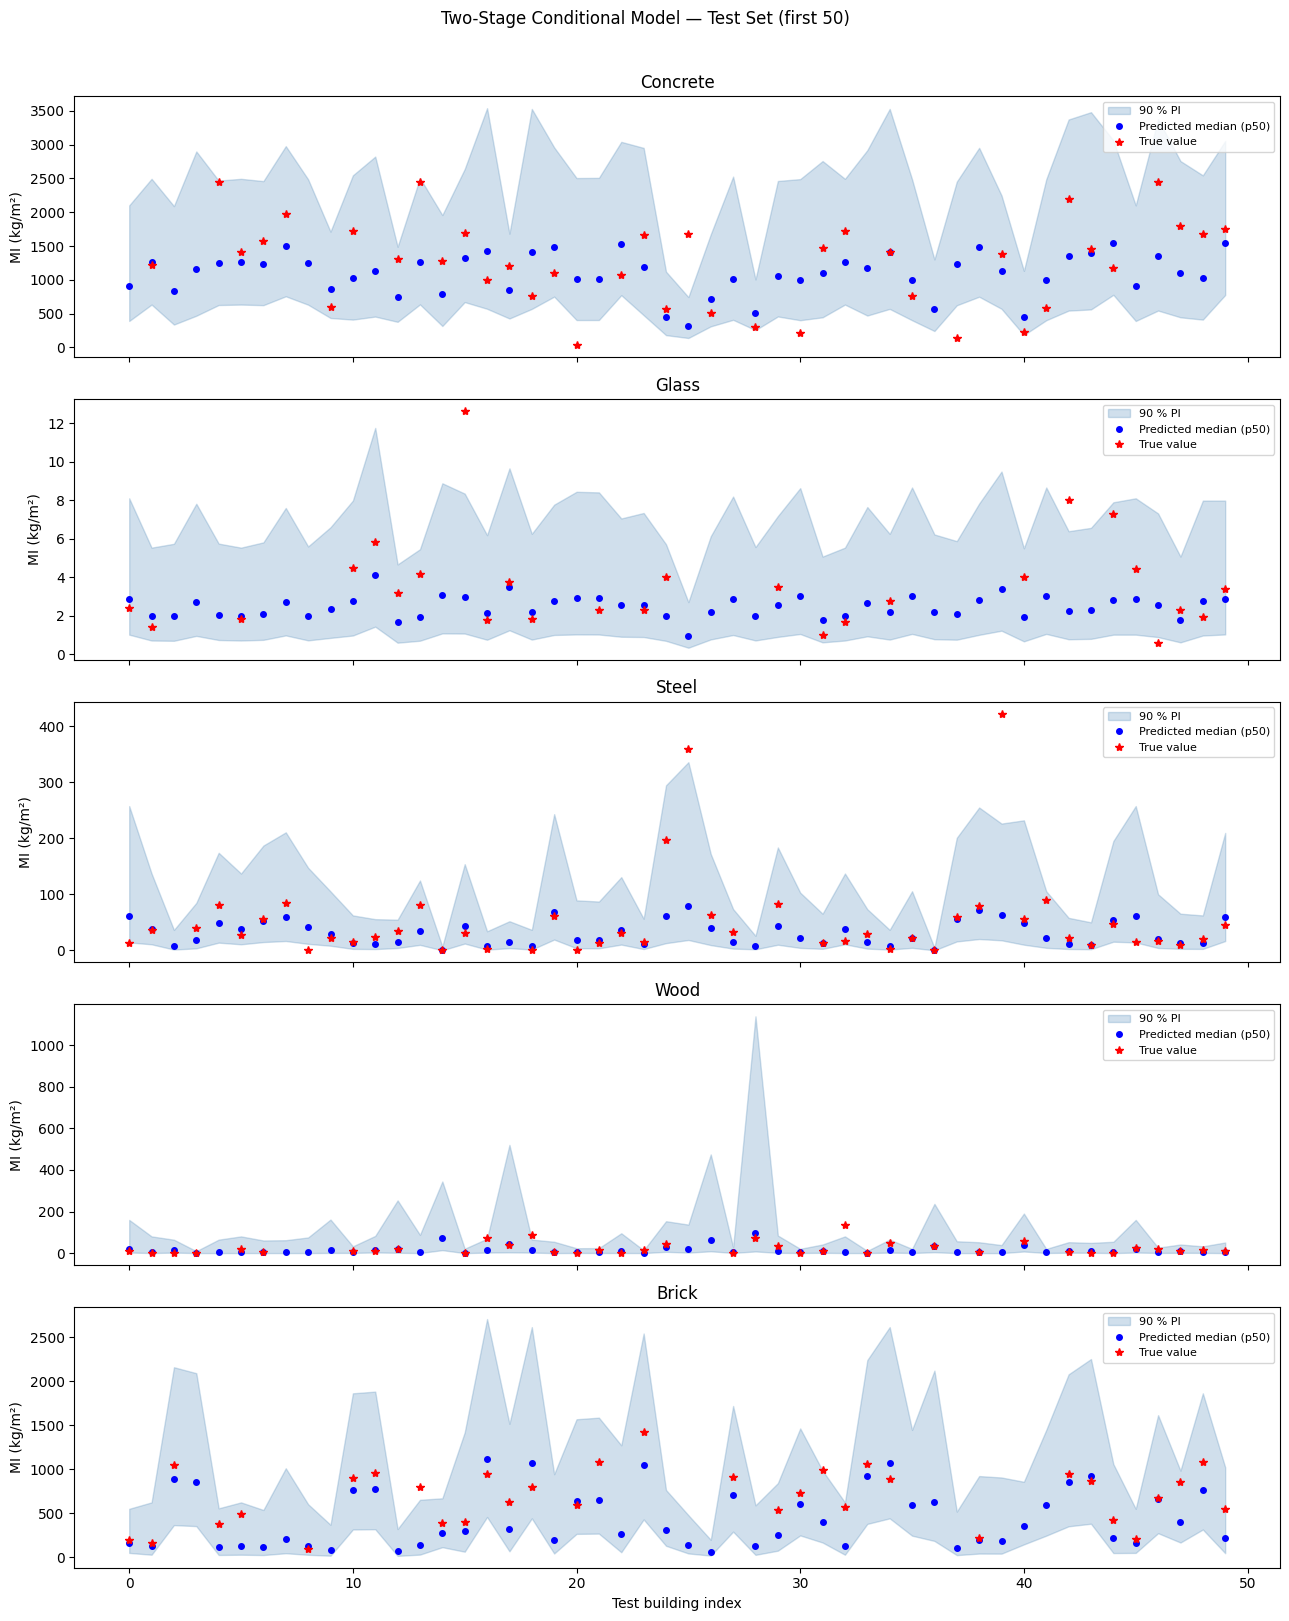

In [38]:
# ==========================================================
# Visualisation — predicted median + 90 % PI vs. true values
#                 (first 50 test-set buildings)
# ==========================================================

n_plot = 50
pred_plot = model.predict(data["X_test_proc"][:n_plot], data["groups_test"][:n_plot], alpha=0.10)

fig, axes = plt.subplots(5, 1, figsize=(13, 16), sharex=True)
x_idx = np.arange(n_plot)

for i, mat in enumerate(y_cols):
    ax = axes[i]
    y_true = data["y_test_df"][mat].iloc[:n_plot].to_numpy(dtype=float)
    observed = ~np.isnan(y_true)
    y_true_plot = y_true.copy()
    y_true_plot[~observed] = np.nan

    ax.fill_between(x_idx, pred_plot[mat]["p5"], pred_plot[mat]["p95"],
                    alpha=0.25, color="steelblue", label="90 % PI")
    ax.plot(x_idx, pred_plot[mat]["p50"], "bo", ms=4, label="Predicted median (p50)")
    ax.plot(x_idx, y_true_plot, "r*", ms=6, label="True value")
    ax.set_title(mat)
    ax.set_ylabel("MI (kg/m\u00b2)")
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Test building index")
plt.suptitle("Two-Stage Conditional Model \u2014 Test Set (first 50)", y=1.01)
plt.tight_layout()
plt.show()


Complete-case test rows: 135
  mean_vector_mae: 106.54
  cov_frobenius: 3.6295e+05
  corr_frobenius: 1.1131
  kl_true_to_pred: 60.923
  kl_pred_to_true: 4.3508


,material,true_mean,pred_mean,abs_mean_diff,true_std,pred_std,abs_std_diff
0,Concrete,1654.170734,1256.800917,397.369817,636.373380,219.992774,416.380606
1,Glass,2.922884,2.369540,0.553345,2.349873,0.417158,1.932715
2,Steel,25.643327,22.872404,2.770923,38.475675,16.055479,22.420196
3,Wood,23.603882,9.994444,13.609438,23.055424,11.238050,11.817374
4,Brick,682.684163,564.265771,118.418393,300.128005,326.065672,25.937667


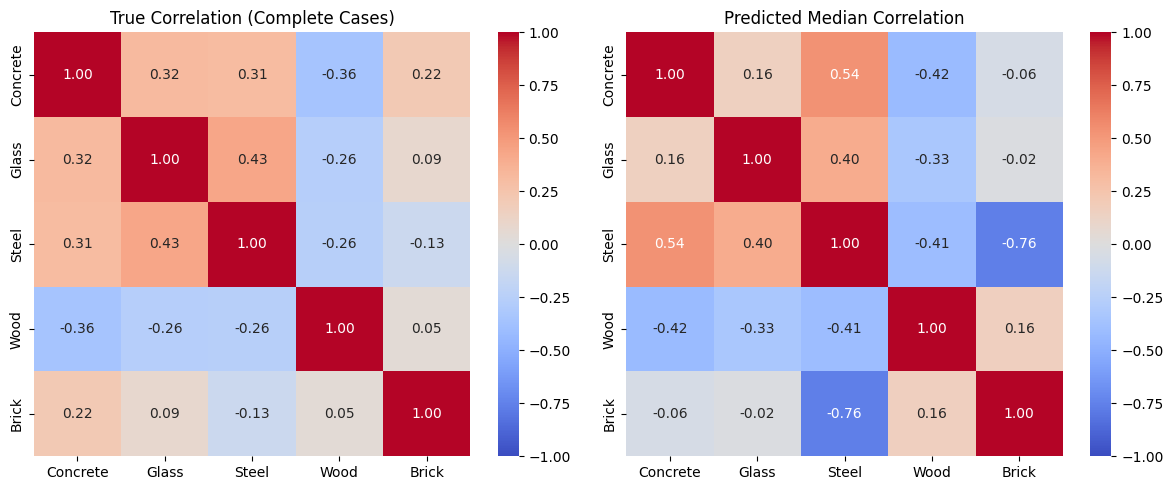

In [39]:
# ==========================================================
# Joint distribution evaluation
#   - Marginal moments (complete-case rows)
#   - Material correlation heatmaps (true vs. predicted)
# ==========================================================

def _gaussian_kl(mu_p, cov_p, mu_q, cov_q, eps=1e-6):
    d = mu_p.shape[0]
    cov_p_r = cov_p + np.eye(d) * eps
    cov_q_r = cov_q + np.eye(d) * eps
    sp, ldp = np.linalg.slogdet(cov_p_r)
    sq, ldq = np.linalg.slogdet(cov_q_r)
    if sp <= 0 or sq <= 0:
        return np.nan
    inv_q = np.linalg.inv(cov_q_r)
    return 0.5 * (np.trace(inv_q @ cov_p_r)
                  + (mu_q - mu_p) @ inv_q @ (mu_q - mu_p)
                  - d + (ldq - ldp))


cc = ~np.isnan(data["y_test_raw"]).any(axis=1)
y_tc = data["y_test_raw"][cc]
y_pc = model.stage2.predict(data["X_test_proc"][cc])

mu_t, mu_p   = y_tc.mean(0), y_pc.mean(0)
std_t, std_p = y_tc.std(0, ddof=1), y_pc.std(0, ddof=1)
cov_t  = np.cov(y_tc, rowvar=False)
cov_p  = np.cov(y_pc, rowvar=False)
corr_t = np.corrcoef(y_tc, rowvar=False)
corr_p = np.corrcoef(y_pc, rowvar=False)

print(f"Complete-case test rows: {cc.sum()}")
stats_summary = {
    "mean_vector_mae":  float(np.mean(np.abs(mu_t - mu_p))),
    "cov_frobenius":    float(np.linalg.norm(cov_t - cov_p, ord="fro")),
    "corr_frobenius":   float(np.linalg.norm(corr_t - corr_p, ord="fro")),
    "kl_true_to_pred":  float(_gaussian_kl(mu_t, cov_t, mu_p, cov_p)),
    "kl_pred_to_true":  float(_gaussian_kl(mu_p, cov_p, mu_t, cov_t)),
}
for k, v in stats_summary.items():
    print(f"  {k}: {v:.5g}")

per_material = pd.DataFrame({
    "material": y_cols,
    "true_mean": mu_t, "pred_mean": mu_p, "abs_mean_diff": np.abs(mu_t - mu_p),
    "true_std":  std_t, "pred_std":  std_p, "abs_std_diff":  np.abs(std_t - std_p),
})
display(per_material)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, corr, title in zip(axes, [corr_t, corr_p],
                            ["True Correlation (Complete Cases)", "Predicted Median Correlation"]):
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
                xticklabels=y_cols, yticklabels=y_cols, ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()


In [40]:
# ==========================================================
# Save artefacts
# ==========================================================

# Rebind classes to the importable module path before pickling.
# This prevents __main__-scoped notebook classes from breaking joblib.load elsewhere.
import two_stage_model as tsm

model.__class__ = tsm.TwoStageConditionalModel
model.stage1.__class__ = tsm.MaterialOccurrenceModel
model.stage2.__class__ = tsm.MaterialIntensityModel
model.joint.__class__ = tsm.JointDistributionModel

joblib.dump(data["preprocessor"], "preprocessor.joblib")
joblib.dump(model, "model.joblib")

model_info = {
    "model_type":  "TwoStageConditionalModel",
    "stage1":      "LogisticRegression (per-material)",
    "stage2":      "RidgeCV in log-space (per-material)",
    "joint_layer": "MultivariateNormal with group-specific covariance",
    "group_cols":  list(GROUP_COLS),
    "y_cols":      y_cols,
    "X_cols":      X_cols,
    "ridge_alphas": list(model.stage2.alphas),
    "stage2_best_alphas": {
        mat: float(model.stage2.models_[mat].alpha_)
        for mat in y_cols if model.stage2.models_.get(mat) is not None
    },
}
with open("model_info.json", "w", encoding="utf-8") as f:
    json.dump(model_info, f, indent=2)

print("Saved: preprocessor.joblib,  model.joblib,  model_info.json")

Saved: preprocessor.joblib,  model.joblib,  model_info.json


In [41]:
# ==========================================================
# Validation 1 — Coverage, Interval Width, Median MAE
# ==========================================================

coverage_results = []
for mat in y_cols:
    y_true = data["y_test_df"][mat].to_numpy(dtype=float)
    obs    = ~np.isnan(y_true)
    y_true = y_true[obs]
    q05 = pred_test[mat]["p5"][obs]
    q50 = pred_test[mat]["p50"][obs]
    q95 = pred_test[mat]["p95"][obs]
    widths = q95 - q05
    coverage_results.append({
        "material":     mat,
        "coverage_90":  round(float(np.mean((y_true >= q05) & (y_true <= q95))), 4),
        "mean_width":   round(float(widths.mean()), 2),
        "median_width": round(float(np.median(widths)), 2),
        "p50_mae":      round(mean_absolute_error(y_true, q50), 4),
    })

coverage_df = pd.DataFrame(coverage_results)
print("===== Coverage / Width / p50 MAE =====")
print(coverage_df.to_string(index=False))

===== Coverage / Width / p50 MAE =====
material  coverage_90  mean_width  median_width  p50_mae
Concrete       0.8148     2099.12       2136.13 620.5385
   Glass       0.9016        6.20          6.35   1.2701
   Steel       0.8873      138.06        109.33  25.3395
    Wood       0.8339       98.76         50.54  14.1124
   Brick       0.9242     1306.43       1319.12 268.6445


In [42]:
# ==========================================================
# Validation 5 — Baseline Comparison (training-set median)
# ==========================================================

baseline_results = []
for i, mat in enumerate(y_cols):
    tr = data["y_train_raw"][:, i]
    tr = tr[~np.isnan(tr)]
    train_median = float(np.median(tr)) if len(tr) > 0 else 0.0

    y_true = data["y_test_df"][mat].to_numpy(dtype=float)
    obs    = ~np.isnan(y_true)
    y_true = y_true[obs]

    b_mae = mean_absolute_error(y_true, np.full_like(y_true, train_median))
    m_mae = coverage_df.loc[coverage_df["material"] == mat, "p50_mae"].values[0]

    baseline_results.append({
        "Material":        mat,
        "Baseline MAE":    round(b_mae, 2),
        "Model MAE":       round(float(m_mae), 2),
        "Improvement (%)": round((b_mae - m_mae) / b_mae * 100, 1) if b_mae > 0 else float("nan"),
    })

print("===== Baseline Comparison =====")
print(pd.DataFrame(baseline_results).to_string(index=False))


===== Baseline Comparison =====
Material  Baseline MAE  Model MAE  Improvement (%)
Concrete        662.18     620.54              6.3
   Glass          1.42       1.27             10.5
   Steel         30.40      25.34             16.6
    Wood         17.62      14.11             19.9
   Brick        301.84     268.64             11.0
